<a href="https://colab.research.google.com/github/ddecosmo-dev/24-782_Third_Eye_Project/blob/main/manual_dataset_training!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This will be used for training the manual dataset gathered from hiking and web scraped hiking images.

Could be very useful for edge device gt

This is all going to be using a dataset based on hiking images rated either 0 or 1 by 3 voters.

This is a basic gt dataset

# Section 1
Dataset updates,
1st, update score to be 0, 0.3, 0.6, 1.0 depending on consensus. Cann allow for additional good and bad images and improve training data

Current Schema


Load dataset, redo scores to be 0, 0.3, 0.6, 1.0

Create intiial train test split!

Test 70%
Val 15%
Test 15%


In [24]:
# Install datasets if you haven't already:
!pip install datasets torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.4 MB/s eta 0:00:00


In [17]:
from datasets import load_dataset, DatasetDict

# 1. Load the dataset
dataset = load_dataset("ddecosmo/third-eye_master_dataset", split="train")

#later after initial training, maybe try removing walk 4 if it is a problem

# 2. Update the scores based on consensus
def calculate_consensus(example):
    total_votes = example['A_score'] + example['D_score'] + example['G_score']

    if total_votes == 0:
        consensus_score = 0.0
    elif total_votes == 1:
        consensus_score = 0.3
    elif total_votes == 2:
        consensus_score = 0.6
    else:
        consensus_score = 1.0

    example['score'] = consensus_score
    # Create a string label specifically for stratification
    example['stratify_label'] = str(consensus_score)
    return example

updated_dataset = dataset.map(calculate_consensus)

# HuggingFace requires the column to be a ClassLabel type for stratification
updated_dataset = updated_dataset.class_encode_column("stratify_label")

# 3. Create the Train (70%), Val (15%), Test (15%) split using STRATIFICATION
train_test_split = updated_dataset.train_test_split(
    test_size=0.3,
    seed=42,
    stratify_by_column="stratify_label" # <--- The magic happens here
)

val_test_split = train_test_split['test'].train_test_split(
    test_size=0.5,
    seed=42,
    stratify_by_column="stratify_label" # <--- And here
)

final_dataset = DatasetDict({
    'train': train_test_split['train'],
    'validation': val_test_split['train'],
    'test': val_test_split['test']
})

# Clean up by removing the temporary stratification column
final_dataset = final_dataset.remove_columns("stratify_label")

print("Dataset successfully processed and cleanly stratified!")

Dataset successfully processed and cleanly stratified!


In [18]:
print(final_dataset)

import pandas as pd

def print_distribution(ds_dict):
    """Prints the count and percentage of each score per split."""
    for split_name, dataset_split in ds_dict.items():
        print(f"--- {split_name.upper()} Split Distribution ---")

        # Convert the 'score' column to a pandas Series for easy counting
        scores = pd.Series(dataset_split['score'])

        # Calculate counts and percentages
        counts = scores.value_counts().sort_index()
        percentages = (scores.value_counts(normalize=True) * 100).sort_index()

        # Create a summary table
        summary = pd.DataFrame({
            'Score': counts.index,
            'Count': counts.values,
            'Percentage (%)': percentages.values
        }).set_index('Score')

        print(summary)
        print("-" * 40)

# Run the check on your pre-augmented dataset
print_distribution(final_dataset)

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'filename', 'walk_index', 'score', 'A_voted', 'D_voted', 'G_voted', 'A_score', 'D_score', 'G_score'],
        num_rows: 1327
    })
    validation: Dataset({
        features: ['image_id', 'image', 'filename', 'walk_index', 'score', 'A_voted', 'D_voted', 'G_voted', 'A_score', 'D_score', 'G_score'],
        num_rows: 284
    })
    test: Dataset({
        features: ['image_id', 'image', 'filename', 'walk_index', 'score', 'A_voted', 'D_voted', 'G_voted', 'A_score', 'D_score', 'G_score'],
        num_rows: 285
    })
})
--- TRAIN Split Distribution ---
       Count  Percentage (%)
Score                       
0.0      781       58.854559
0.3      241       18.161266
0.6      187       14.091937
1.0      118        8.892238
----------------------------------------
--- VALIDATION Split Distribution ---
       Count  Percentage (%)
Score                       
0.0      167       58.802817
0.3       51       17.957746


# Section 2 Augmentation

Lets start with basic augmentations.

1. horizontal flips

Consider more?
IMPORTANT
since the score is so coarse, and there arent that many voters. Augmentations must not change the score of the image as there is not an easily understandable way to do this.

After augmentation, we can push to hugging face as part of a new dataset.

Augmented data should contain the original parent idx, along with the augmented idx number

In [19]:
import torchvision.transforms.functional as TF
import torch
import random
import numpy as np
from PIL import Image, ImageEnhance
from datasets import Dataset

def apply_safe_augmentations(image, p_flip=0.5, p_rotate=0.5, p_jitter=0.5):
    """
    Applies score-safe transforms using reflection padding to
    maintain 320x240 resolution without black bar artifacts.
    """
    img = image.copy()

    # 1. Horizontal Flip (Proportional)
    if random.random() < p_flip:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # 2. Subtle Rotation with Reflection Padding
    if random.random() < p_rotate:
        angle = random.uniform(-4, 4)

        # We pad the image before rotating to give 'mirror' pixels to pull from
        # Padding by 15 pixels is plenty for a 4-degree rotation
        padded_img = TF.pad(img, padding=15, padding_mode="reflect")
        rotated_padded = TF.rotate(padded_img, angle, interpolation=TF.InterpolationMode.BILINEAR)

        # Crop back to original dimensions (320x240) to remove the padding
        # This effectively fills the 'corners' with mirrored trail data
        w, h = img.size
        img = TF.center_crop(rotated_padded, [h, w])

    # 3. Mild Brightness and Contrast (Proportional)
    if random.random() < p_jitter:
        brightness_factor = random.uniform(0.9, 1.1)
        contrast_factor = random.uniform(0.9, 1.1)
        img = ImageEnhance.Brightness(img).enhance(brightness_factor)
        img = ImageEnhance.Contrast(img).enhance(contrast_factor)

    return img

def augment_dataset_split(split_dataset, multipliers):
    augmented_rows = []
    for idx, example in enumerate(split_dataset):
        score = example['score']
        m = multipliers.get(score, 1)

        # Keep Original
        orig = example.copy()
        orig['parent_idx'], orig['aug_id'] = idx, 0
        augmented_rows.append(orig)

        # Create Augmented Versions
        for aug_num in range(1, m):
            new_row = example.copy()
            new_row['image'] = apply_safe_augmentations(example['image'])
            new_row['parent_idx'], new_row['aug_id'] = idx, aug_num
            augmented_rows.append(new_row)

    return Dataset.from_list(augmented_rows)

# Execute Augmentation
AUG_CONFIG = {0.0: 1, 0.3: 2, 0.6: 3, 1.0: 4}
final_dataset['train'] = augment_dataset_split(final_dataset['train'], AUG_CONFIG)

In [20]:
print(f"New Training Set Size: {len(final_dataset['train'])}")
print_distribution(final_dataset)

New Training Set Size: 2296
--- TRAIN Split Distribution ---
       Count  Percentage (%)
Score                       
0.0      781       34.015679
0.3      482       20.993031
0.6      561       24.433798
1.0      472       20.557491
----------------------------------------
--- VALIDATION Split Distribution ---
       Count  Percentage (%)
Score                       
0.0      167       58.802817
0.3       51       17.957746
0.6       41       14.436620
1.0       25        8.802817
----------------------------------------
--- TEST Split Distribution ---
       Count  Percentage (%)
Score                       
0.0      168       58.947368
0.3       52       18.245614
0.6       40       14.035088
1.0       25        8.771930
----------------------------------------


Filter:   0%|          | 0/2296 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2296 [00:00<?, ? examples/s]

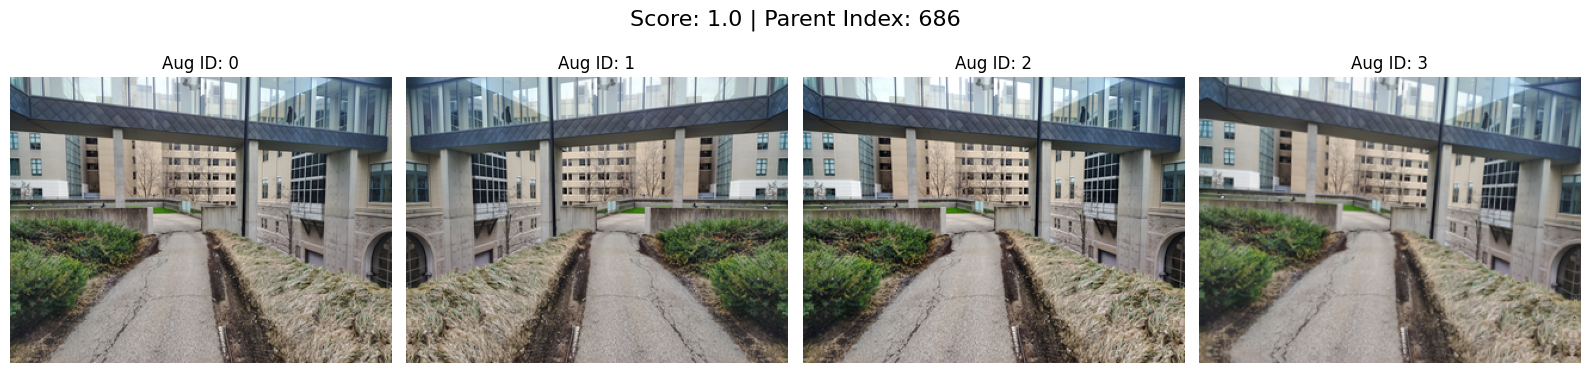

In [21]:
import matplotlib.pyplot as plt

def visualize_augmentations(dataset, target_score, num_samples=1):
    """
    Finds a parent image with the target_score and displays it
    alongside all its augmented children.
    """
    # Filter dataset for the specific score and only original images (aug_id == 0)
    parents = dataset.filter(lambda x: x['score'] == target_score and x['aug_id'] == 0)

    if len(parents) == 0:
        print(f"No images found with score {target_score}")
        return

    # Select random parent indices
    indices = random.sample(range(len(parents)), min(num_samples, len(parents)))

    for p_idx in indices:
        parent_example = parents[p_idx]
        parent_orig_idx = parent_example['parent_idx']

        # Get all children for this parent
        family = dataset.filter(lambda x: x['parent_idx'] == parent_orig_idx)

        cols = len(family)
        fig, axes = plt.subplots(1, cols, figsize=(cols * 4, 4))
        fig.suptitle(f"Score: {target_score} | Parent Index: {parent_orig_idx}", fontsize=16)

        # If there's only one image, axes isn't a list
        if cols == 1:
            axes = [axes]

        for i, member in enumerate(family):
            axes[i].imshow(member['image'])
            axes[i].set_title(f"Aug ID: {member['aug_id']}")
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

# Example Usage:
visualize_augmentations(final_dataset['train'], target_score=1.0)

# Section 3 Model Setup!

1. ResNet or MobileNet, tuned to dataset

2. DinoV2 / V3 w/ MLP heads

3. MaskFormer w/ MLP heads

Loss functions.

1. MSE or Standard Loss
2. EMD? Could be used since we have 2 main classes and 2 sub classes
3. Triplet Loss? Very interesting! have 2 spectrums and middle value


Going with BCE, sets soft labels and can hopefully generalize to a large array of image qualities!



In [29]:
import torch

try:
    # Attempting to load a mirrored version of DINOv3 (ViT-S/16) from HF
    model_v3_backbone = torch.hub.load('facebookresearch/dinov3', 'dinov3_vits16', pretrained=True, skip_validation=True)
    print("Successfully bypassed 403 via validation skip!")
except:
    print("Still blocked. Let's move to the reliable alternative.")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main


Downloading: "https://dl.fbaipublicfiles.com/dinov3/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vits16_pretrain_lvd1689m-08c60483.pth
Still blocked. Let's move to the reliable alternative.


In [32]:
import torch
import torch.nn as nn
from transformers import AutoModel

class HolisticPathRater(nn.Module):
    def __init__(self):
        super(HolisticPathRater, self).__init__()
        # Load the frozen DINOv2 backbone (ViT-Small)
        print("Loading DINOv2 backbone: facebook/dinov2-small...")
        self.backbone = AutoModel.from_pretrained("facebook/dinov2-small")
        self.embed_dim = 384

        # Freeze backbone parameters entirely
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Standard MLP Head (No Dropout as requested)
        # Using GELU to stay consistent with Transformer architectures
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        # Extract the CLS token (index 0)
        cls_token = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_token)
        return logits.squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HolisticPathRater().to(device)

print("Model initialized on:", device)

Loading DINOv2 backbone: facebook/dinov2-small...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model initialized on: cpu


# Section 4 Training

Create the training loops,
run training
inspect results

Add regularization as needed to get solid results

In [33]:
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

# 1. Image Pre-processing for DINOv2
dino_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def collate_fn(batch):
    # Convert images to RGB and apply DINO transforms
    images = [dino_transform(item['image'].convert("RGB")) for item in batch]
    # Keep scores as float32 for BCEWithLogitsLoss
    labels = [torch.tensor(item['score'], dtype=torch.float32) for item in batch]
    return torch.stack(images), torch.stack(labels)

# Using the augmented dataset we prepared in Section 2
train_loader = DataLoader(final_dataset['train'], batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(final_dataset['validation'], batch_size=32, collate_fn=collate_fn)

# 2. Optimization Config
# Only optimizing the MLP head; backbone remains frozen
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

# 3. The Training Loop
for epoch in range(10):
    model.train()
    total_train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # Validation Phase
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            val_loss = criterion(logits, labels)
            total_val_loss += val_loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)
    print(f"Epoch {epoch+1}: Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

# Save the resulting "rater" weights
torch.save(model.state_dict(), "path_rater_dinov2.pth")

Epoch 1:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 1: Train Loss: 0.5840 | Val Loss: 0.4542


Epoch 2:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 2: Train Loss: 0.4945 | Val Loss: 0.4229


Epoch 3:   0%|          | 0/72 [00:00<?, ?it/s]

...

Epoch 8: Train Loss: 0.3996 | Val Loss: 0.3812


Epoch 9:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 9: Train Loss: 0.3935 | Val Loss: 0.3781


Epoch 10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 10: Train Loss: 0.3861 | Val Loss: 0.3867


# Section 5: analytics

Do R2 plots, AUC, other analytics to check

Train v Test v Val scores

Gathering Predictions:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_2417/3352786723.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Actual', y='Predicted', data=df, inner="quart", palette="viridis")


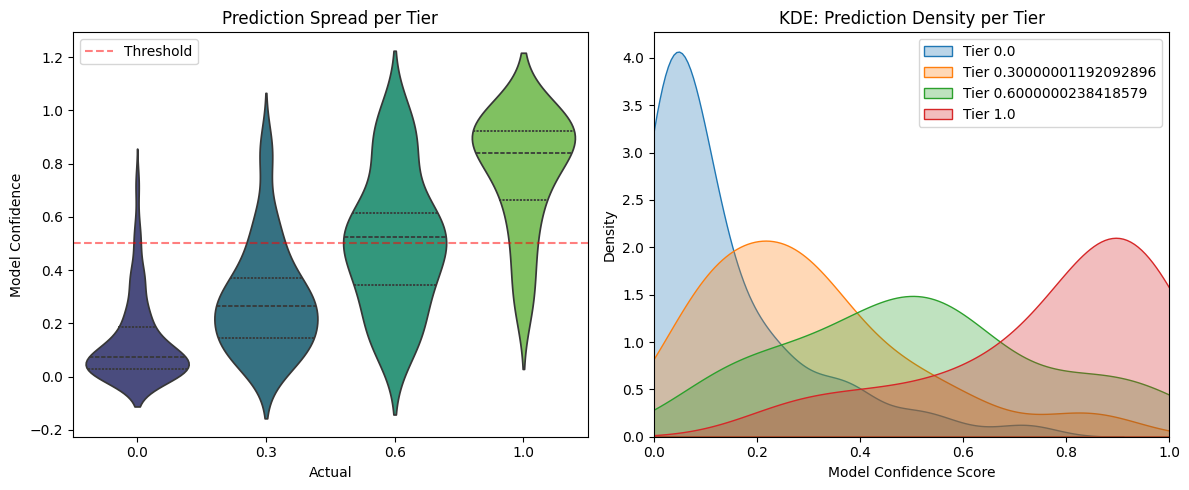


--- Performance Metrics by Tier ---
 Actual     mean      std  count
    0.0 0.134055 0.156754    167
    0.3 0.296755 0.205460     51
    0.6 0.509151 0.251995     41
    1.0 0.768637 0.218821     25


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def run_enhanced_analytics(model, loader):
    model.eval()
    preds = []
    actuals = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Gathering Predictions"):
            images = images.to(device)
            logits = model(images)
            probabilities = torch.sigmoid(logits).cpu().numpy()

            preds.extend(probabilities)
            actuals.extend(labels.numpy())

    df = pd.DataFrame({'Actual': actuals, 'Predicted': preds})

    # --- VISUALIZATION 1: Violin Plot ---
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.violinplot(x='Actual', y='Predicted', data=df, inner="quart", palette="viridis")
    plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Threshold')
    plt.title("Prediction Spread per Tier")
    plt.ylabel("Model Confidence")
    plt.legend()

    # --- VISUALIZATION 2: KDE Plot (Density) ---
    plt.subplot(1, 2, 2)
    for score in sorted(df['Actual'].unique()):
        subset = df[df['Actual'] == score]
        sns.kdeplot(subset['Predicted'], label=f"Tier {score}", fill=True, alpha=0.3)

    plt.title("KDE: Prediction Density per Tier")
    plt.xlabel("Model Confidence Score")
    plt.ylabel("Density")
    plt.xlim(0, 1)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Summary Table
    results = df.groupby('Actual')['Predicted'].agg(['mean', 'std', 'count']).reset_index()
    print("\n--- Performance Metrics by Tier ---")
    print(results.to_string(index=False))

    return df

# Run on validation set
analysis_df = run_enhanced_analytics(model, val_loader)

Gathering Predictions:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_2417/3352786723.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Actual', y='Predicted', data=df, inner="quart", palette="viridis")


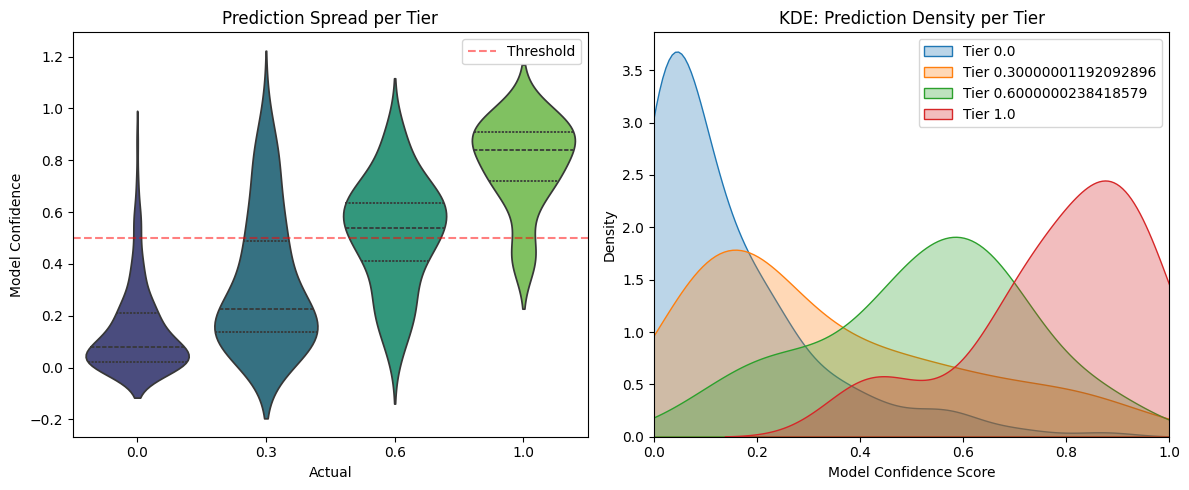


--- Performance Metrics by Tier ---
 Actual     mean      std  count
    0.0 0.141217 0.162596    168
    0.3 0.332161 0.257407     52
    0.6 0.518255 0.207814     40
    1.0 0.786265 0.170407     25


In [37]:
# 1. First, define the test loader if you haven't already
test_loader = DataLoader(final_dataset['test'], batch_size=32, collate_fn=collate_fn)

# Run on the TEST set
test_results_df = run_enhanced_analytics(model, test_loader)

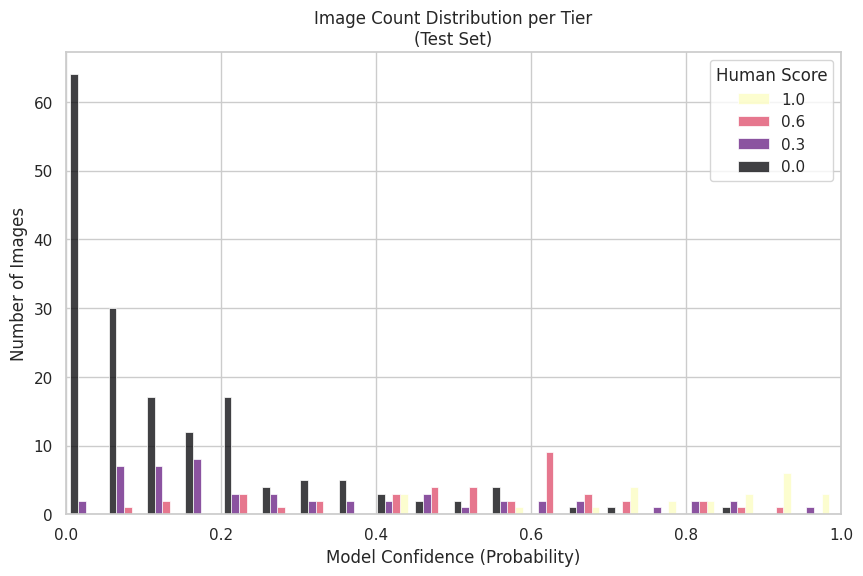

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_frequency_bars(df, title_suffix="Test Set"):
    """
    Plots a distribution where the Y-axis is the raw image count
    using a grouped bar chart (histogram) without KDE lines.
    """
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    # element="bars" and kde=False removes the lines
    # multiple="dodge" places bars side-by-side for each tier
    sns.histplot(
        data=df,
        x='Predicted',
        hue='Actual',
        kde=False,
        element="bars",
        stat="count",
        palette="magma",
        multiple="dodge",
        shrink=0.8,      # Adds small gaps between groups for readability
        bins=20          # Adjust bins to change the granularity of the X-axis
    )

    plt.title(f"Image Count Distribution per Tier\n({title_suffix})")
    plt.xlabel("Model Confidence (Probability)")
    plt.ylabel("Number of Images")
    plt.xlim(0, 1)

    # Sort legend to match consensus tiers
    plt.legend(title="Human Score", labels=sorted(df['Actual'].unique(), reverse=True))

    plt.show()

# --- Execution ---
plot_frequency_bars(test_results_df, title_suffix="Test Set")

#Section 7

Additional TESTING

Let see where we could place a cutoff to maximize the amount of positive images
1.0 and 0.6 while minimizing 0.3 and 0.0. Needs to be charitable enough to get a large number of images but not punish a huge amount of them.

Could this be a cost function or a gradient descent method?

#COME BACK AND FIX UP FOR REPORT!

In [44]:
#weighted Utlitiy

import pandas as pd
import numpy as np

def analyze_gate_utility(df,
                         weights={1.0: 10, 0.6: 5, 0.3: -2, 0.0: -10},
                         prob_col='pred_prob',
                         label_col='actual_score'):
    """
    Calculates the 'Utility' of different thresholds based on custom weights.
    Higher weights for 1.0/0.6 reward keeping them.
    Negative weights for 0.3/0.0 penalize letting them through.
    """
    thresholds = np.linspace(0, 1, 101)
    results = []

    # Pre-calculate counts for each class
    total_counts = df[label_col].value_counts().to_dict()

    for t in thresholds:
        passed = df[df[prob_col] >= t]
        passed_counts = passed[label_col].value_counts().to_dict()

        # Calculate Recall per class
        stats = {'Threshold': t}
        utility = 0
        for score in [1.0, 0.6, 0.3, 0.0]:
            total = total_counts.get(score, 0)
            kept = passed_counts.get(score, 0)
            recall = kept / total if total > 0 else 0

            stats[f'Recall_{score}'] = recall
            utility += recall * weights.get(score, 0)

        stats['Utility_Score'] = utility
        stats['Total_Pass_Rate'] = len(passed) / len(df)
        results.append(stats)

    return pd.DataFrame(results).sort_values('Utility_Score', ascending=False)

In [45]:
# fbeta score

def analyze_gate_fbeta(df,
                       beta=2.0,
                       prob_col='pred_prob',
                       label_col='actual_score'):
    """
    Treats {1.0, 0.6} as Positives and {0.3, 0.0} as Negatives.
    Optimizes for F-Beta score to favor Recall over Precision.
    """
    thresholds = np.linspace(0, 1, 101)
    results = []

    # Define Ground Truth Positives/Negatives
    is_positive = df[label_col] >= 0.6
    total_p = is_positive.sum()

    for t in thresholds:
        is_pred_positive = df[prob_col] >= t

        tp = (is_positive & is_pred_positive).sum()
        fp = (~is_positive & is_pred_positive).sum()
        fn = (is_positive & ~is_pred_positive).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        # F-beta calculation
        if (precision + recall) > 0:
            fbeta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
        else:
            fbeta = 0

        # Detailed stats for individual classes
        stats = {
            'Threshold': t,
            'F_Beta': fbeta,
            'Precision': precision,
            'Recall_Overall': recall,
            'Recall_1.0': (df[(df[label_col] == 1.0) & (df[prob_col] >= t)].shape[0] /
                           df[df[label_col] == 1.0].shape[0]),
            'Leakage_0.0': (df[(df[label_col] == 0.0) & (df[prob_col] >= t)].shape[0] /
                            df[df[label_col] == 0.0].shape[0]),
            'System_Load': is_pred_positive.mean()
        }
        results.append(stats)

    return pd.DataFrame(results).sort_values('F_Beta', ascending=False)

Running analytics on the test set...


Gathering Predictions:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_2417/3352786723.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Actual', y='Predicted', data=df, inner="quart", palette="viridis")


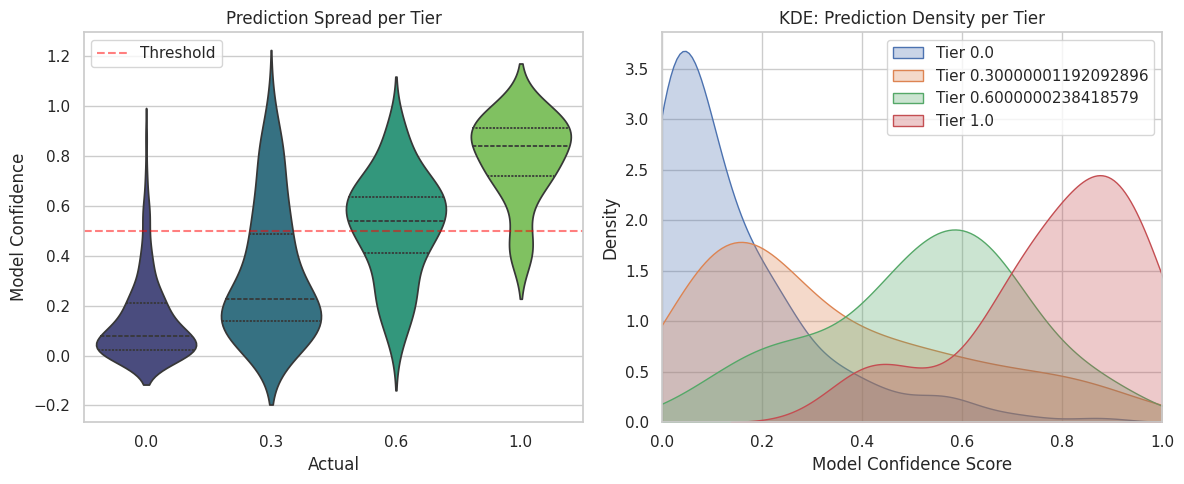


--- Performance Metrics by Tier ---
 Actual     mean      std  count
    0.0 0.141217 0.162596    168
    0.3 0.332161 0.257407     52
    0.6 0.518255 0.207814     40
    1.0 0.786265 0.170407     25

--- GATEKEEPER RECOMMENDATIONS ---
Max Utility Threshold: 0.600 (Best balance of rewards vs. waste)
Max F-Beta Threshold:  0.200 (Safety-first: minimizes image loss)


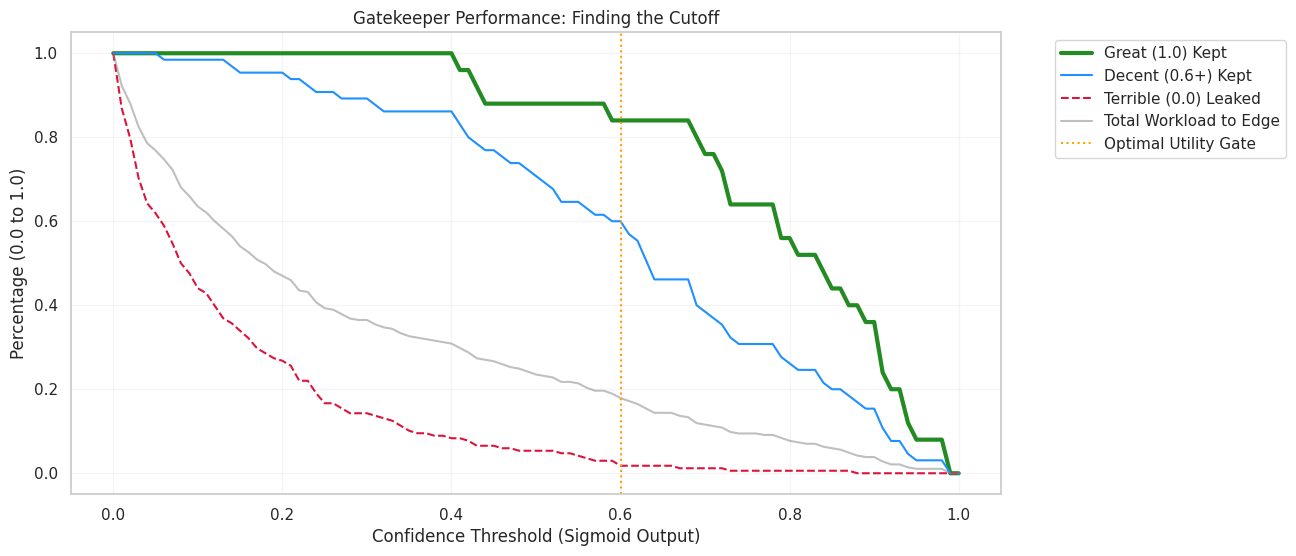


--- Statistics at Threshold 0.600 ---
Total Workload Reduced: 82.1%
Percentage of 1.0s Saved: 84.0%
Percentage of 0.0s Filtered: 98.2%


In [46]:
# --- SECTION 7: GATEKEEPER OPTIMIZATION ---

# 1. Gather predictions on the test set
print("Running analytics on the test set...")
analysis_df_test = run_enhanced_analytics(model, test_loader)

# Ensure 'Predicted' column is a simple float (sometimes returned as a single-element array)
analysis_df_test['Predicted'] = analysis_df_test['Predicted'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)

def evaluate_gate_logic(df, thresholds=np.linspace(0, 1, 101)):
    """
    Calculates metrics for every threshold to find the optimal gate.
    """
    gate_data = []

    # Define our target groups
    positives = df[df['Actual'] >= 0.6]  # 0.6 and 1.0
    perfects = df[df['Actual'] == 1.0]
    terribles = df[df['Actual'] == 0.0]

    for t in thresholds:
        passed = df[df['Predicted'] >= t]

        # Calculate key metrics
        recall_1_0 = (passed['Actual'] == 1.0).sum() / len(perfects) if len(perfects) > 0 else 0
        recall_pos = (passed['Actual'] >= 0.6).sum() / len(positives) if len(positives) > 0 else 0
        leakage_0_0 = (passed['Actual'] == 0.0).sum() / len(terribles) if len(terribles) > 0 else 0
        pass_rate = len(passed) / len(df)

        # Weighted Utility (Rewards: 1.0=+10, 0.6=+5 | Penalties: 0.3=-5, 0.0=-15)
        # Note: We use counts here to weigh the impact on the total stream
        utility = (
            (passed['Actual'] == 1.0).sum() * 10 +
            (passed['Actual'] == 0.6).sum() * 5 +
            (passed['Actual'] == 0.3).sum() * -5 +
            (passed['Actual'] == 0.0).sum() * -15
        )

        # F-Beta Score (Beta=3 weights Recall 3x more than Precision)
        # Treating 0.6+ as Positives
        tp = (passed['Actual'] >= 0.6).sum()
        fp = (passed['Actual'] < 0.6).sum()
        fn = (df['Actual'] >= 0.6).sum() - tp

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        beta = 3.0
        f_beta = (1 + beta**2) * (prec * rec) / ((beta**2 * prec) + rec) if (prec + rec) > 0 else 0

        gate_data.append({
            'Threshold': t,
            'Recall_1.0': recall_1_0,
            'Recall_0.6+': recall_pos,
            'Leakage_0.0': leakage_0_0,
            'Pass_Rate': pass_rate,
            'Utility': utility,
            'F_Beta': f_beta
        })

    return pd.DataFrame(gate_data)

# 2. Run the analysis
gate_results = evaluate_gate_logic(analysis_df_test)

# 3. Find Optimal Thresholds
best_utility = gate_results.loc[gate_results['Utility'].idxmax()]
best_fbeta = gate_results.loc[gate_results['F_Beta'].idxmax()]

print(f"\n--- GATEKEEPER RECOMMENDATIONS ---")
print(f"Max Utility Threshold: {best_utility['Threshold']:.3f} (Best balance of rewards vs. waste)")
print(f"Max F-Beta Threshold:  {best_fbeta['Threshold']:.3f} (Safety-first: minimizes image loss)")

# 4. Final Visualization
plt.figure(figsize=(12, 6))
plt.plot(gate_results['Threshold'], gate_results['Recall_1.0'], label='Great (1.0) Kept', color='forestgreen', lw=3)
plt.plot(gate_results['Threshold'], gate_results['Recall_0.6+'], label='Decent (0.6+) Kept', color='dodgerblue')
plt.plot(gate_results['Threshold'], gate_results['Leakage_0.0'], label='Terrible (0.0) Leaked', color='crimson', linestyle='--')
plt.plot(gate_results['Threshold'], gate_results['Pass_Rate'], label='Total Workload to Edge', color='gray', alpha=0.5)

plt.axvline(best_utility['Threshold'], color='orange', linestyle=':', label='Optimal Utility Gate')
plt.title("Gatekeeper Performance: Finding the Cutoff")
plt.xlabel("Confidence Threshold (Sigmoid Output)")
plt.ylabel("Percentage (0.0 to 1.0)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

# Show the breakdown at the recommended Utility threshold
t_opt = best_utility['Threshold']
final_pass = analysis_df_test[analysis_df_test['Predicted'] >= t_opt]
print(f"\n--- Statistics at Threshold {t_opt:.3f} ---")
print(f"Total Workload Reduced: {100 - (len(final_pass)/len(analysis_df_test)*100):.1f}%")
print(f"Percentage of 1.0s Saved: {best_utility['Recall_1.0']*100:.1f}%")
print(f"Percentage of 0.0s Filtered: {(1 - best_utility['Leakage_0.0'])*100:.1f}%")

## Section 8: Model and Data Saving!!!!!!

Lets save the model as a .pth or .pkl file so we can load it very very easily!

In [ ]:
# add augmented dataset to Huggingface!!!

In [ ]:
#save MLP file!!!!!